**End-to-end Machine Learning project**

Chào mừng bạn đến với Công ty Bất động sản FTU! Nhiệm vụ của bạn là dự đoán giá trị trung bình của các ngôi nhà trong các khu vực của California, dựa trên một số đặc trưng từ những khu vực này.

# Bước 1: Xác định vấn đề và nhìn nhận tổng quan

## Xác định vấn đề và nhìn nhận tổng quan



*   Notebook này được sử dụng để giải quyết vấn đề dự đoán giá nhà thông qua phương pháp học máy.
*   Xây dựng mô hình học máy để dự đoán giá nhà trong tiểu bang thông qua các đặc trưng: longitude, latitude,	housing_median_age,	total_rooms,total_bedrooms,	population,	households,	median_income,	ocean_proximity.
* Notebook này được sử dụng nhằm mục đích xây dựng mô hình có thể học một số thông tin từ dữ liệu và có khả năng dự đoán giá nhà trung bình trong bất kỳ quận nào.



# Bước 2: Lấy dữ liệu

## Load Dữ liệu

In [1]:
import pandas as pd
import os
def load_housing_data(housing_path):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [2]:
housing = load_housing_data("L12_datasets/housing")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Nhìn nhanh vào cấu trúc dữ liệu

In [3]:
# Kiểm tra 5 dòng đâu tiên của dữ liệu
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# Mô tả nhanh về dữ liệu
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Một số thông tin hữu ích từ Bộ dữ liệu:

1.   Hầu hết các đặc trưng đều có kiểu dữ liệu là float64, trừ ocean_proximity (kiểu object).
2.   Số lượng bản ghi của total_bedrooms ít hơn so với các đặc trưng khác, điều này có nghĩa là có một số giá trị trống (Null) trong đặc trưng này.

In [5]:
# Xem số lượng giá trị danh mục trong đặc trưng ocean_proximity.
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
# Thông tin thống kê từ bộ dữ liệu 
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


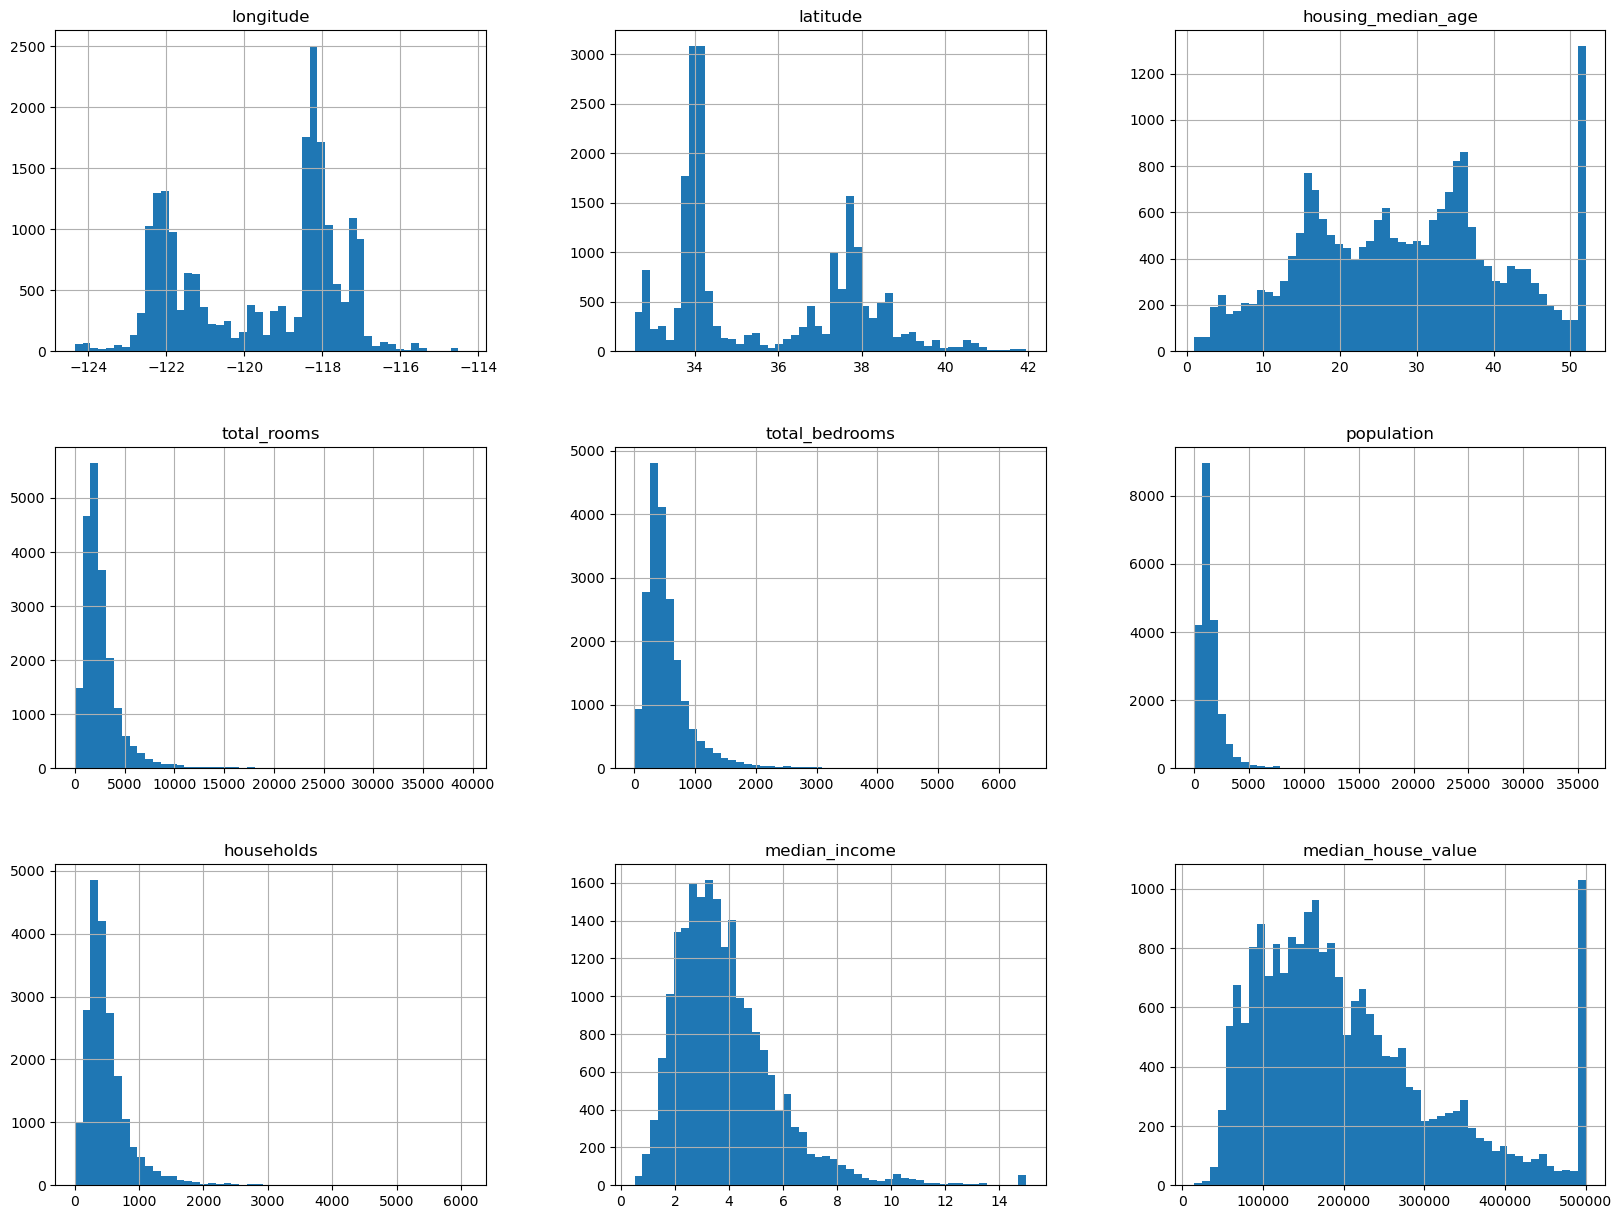

In [7]:
# Vẽ biểu đồ Histogram để xem phân phối của mỗi đặc trưng.
import matplotlib.pyplot as plt
housing.hist(bins = 50, figsize = (20,15))
plt.show()

Một số điểm quan trọng từ biểu đồ Histogram:


*  Thu nhập trung bình của người Mỹ dường như nhỏ hơn so với thông thường, biến này cần phải chuẩn hoá lại.

*  Dữ liệu về độ tuổi trung bình và giá trị trung bình của ngôi nhà có các giá trị lớn bất thường (giá trị ngoại lai), điều này có thể tạo ra độ lệch cho mô hình khi học mẫu này.

* Nhiều đặc trưng có phân phối đuôi dài (tail-heavy), điều này không tốt cho một số mô hình học máy



## Tạo Bộ dữ liệu Kiểm thử

Có vẻ lạ khi tạo Bộ dữ liệu Kiểm thử ở giai đoạn này, nhưng có một số điểm thú vị:

*   Sau khi xem xét thêm chi tiết về dữ liệu, bộ não của chúng ta có thể phát hiện một số đặc trưng (patterns) từ dữ liệu.
*   Chúng ta có thể tình cờ phát hiện một số đặc trưng (patterns) có vẻ thú vị trong bộ dữ liệu kiểm thử, dẫn đến việc chọn một loại mô hình học máy cụ thể cho các đặc trưng này, điều này có thể kiến chúng ta chọn sai mô hình và dễ xảy ra hiện tượng overfitting.
* Khi chúng ta huấn luyện mô hình và sử dụng bộ dữ liệu kiểm thử để điều chỉnh mô hình, ước lượng sẽ quá lạc quan, nhưng khi triển khai hệ thống, nó có thể không hoạt động cũng như dự kiến, vì thế chúng ta cần lấy tập dữ liệu này đại diện dữ liệu thực tế trong môi trường production.

In [8]:
from sklearn.model_selection import train_test_split
Training_set, Testing_set = train_test_split(housing, test_size =0.2, random_state = 42)

In [9]:
Testing_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
15362,-117.22,33.36,16.0,3165.0,482.0,1351.0,452.0,4.6050,263300.0,<1H OCEAN
16623,-120.83,35.36,28.0,4323.0,886.0,1650.0,705.0,2.7266,266800.0,NEAR OCEAN
18086,-122.05,37.31,25.0,4111.0,538.0,1585.0,568.0,9.2298,500001.0,<1H OCEAN
2144,-119.76,36.77,36.0,2507.0,466.0,1227.0,474.0,2.7850,72300.0,INLAND


**Lưu ý quan trọng khi chia bộ dữ liệu:**

* Khi chia dữ liệu, chúng ta cần cân nhắc cẩn thận đến độ lệch của các mẫu quan trọng.
*  Trong dự án này, có một gợi ý từ chuyên gia rằng thu nhập trung bình là một đặc trưng rất quan trọng để dự đoán giá nhà, vì vậy chúng ta cần đảm bảo rằng bộ kiểm thử là đại diện cho các hạng mục thu nhập khác nhau trong toàn bộ bộ dữ liệu.

*  Sử dụng hàm sau để tạo một thuộc tính danh mục thu nhập với năm hạng từ 1 đến 5.


In [10]:
import numpy as np

housing['imcome_cat'] = pd.cut(housing["median_income"], bins = [0,1.5,3,4.5,6,np.inf], labels = [1,2,3,4,5])

imcome_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64


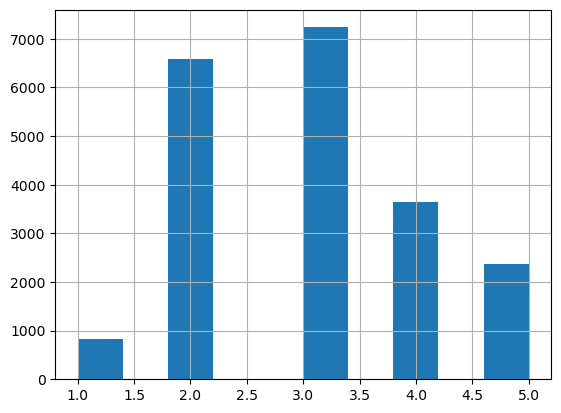

In [11]:
# Vẽ biểu đồ histogram
housing['imcome_cat'].hist()
print(housing['imcome_cat'].value_counts()/len(housing))

In [12]:
# Thực hiện việc lấy mẫu theo lớp (stratified sampling) dựa trên danh mục thu nhập.

from sklearn.model_selection import StratifiedShuffleSplit

Split = StratifiedShuffleSplit(n_splits = 1, test_size = 0.2, random_state = 42)
for train_id, test_id in Split.split(housing, housing['imcome_cat']):
  strat_train_set = housing.loc[train_id]
  strat_test_set = housing.loc[test_id] 

imcome_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64


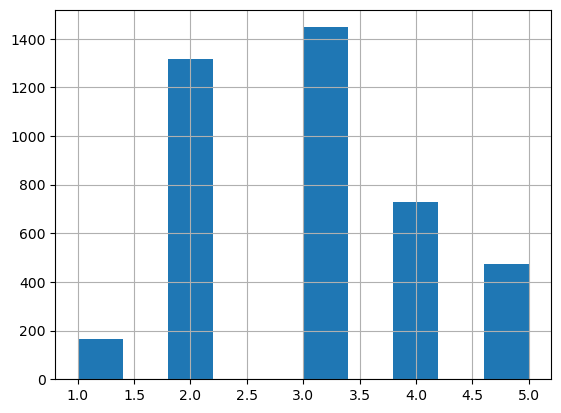

In [13]:
# Vẽ biểu đồ cho dữ liệu bộ kiểm thử mới, xem phân phối của bộ kiểm thử.

strat_test_set.imcome_cat.hist()
print(strat_test_set['imcome_cat'].value_counts()/len(strat_test_set))

Phân phối của bộ dữ liệu kiểm thử có vẻ giống như bộ dữ liệu tổng thể (Population)

In [14]:
strat_train_set.drop("imcome_cat", axis = 1, inplace = True)
strat_test_set.drop("imcome_cat", axis = 1, inplace = True)


# Bước 3: Khám phá và trực quan hoá dữ liệu

In [15]:
Data_Visualization = strat_train_set.copy()

## Trực quan dữ liệu địa lý

<Axes: xlabel='longitude', ylabel='latitude'>

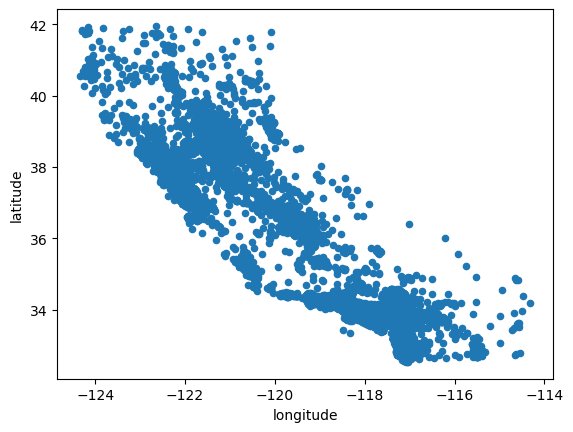

In [16]:
# Vẽ hình dạng của California dựa trên thông tin địa lý.
Data_Visualization.plot(kind='scatter', x = "longitude", y = 'latitude')

<Axes: xlabel='longitude', ylabel='latitude'>

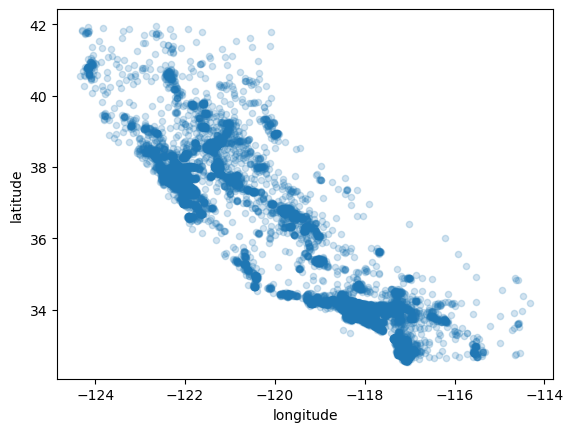

In [17]:
# Hiển thị hình ảnh minh họa các khu vực có mật độ cao.
Data_Visualization.plot(kind='scatter', x = "longitude", y = 'latitude', alpha = 0.2)

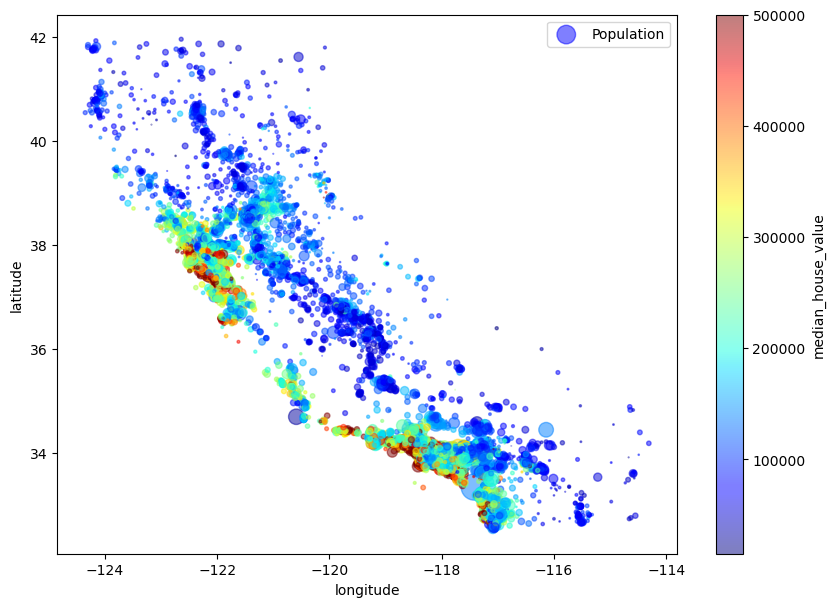

In [18]:
# Giá nhà ở California: Màu đỏ là đắt, màu xanh là rẻ, hình tròn lớn có mật độ dân số cao.
Data_Visualization.plot(kind='scatter', x = "longitude", y = 'latitude', alpha = 0.5, 
                        s = Data_Visualization["population"]/100, label = 'Population', figsize = (10,7),
                        c = "median_house_value", cmap = plt.get_cmap("jet"),
                        colorbar = True
                        )
plt.legend()

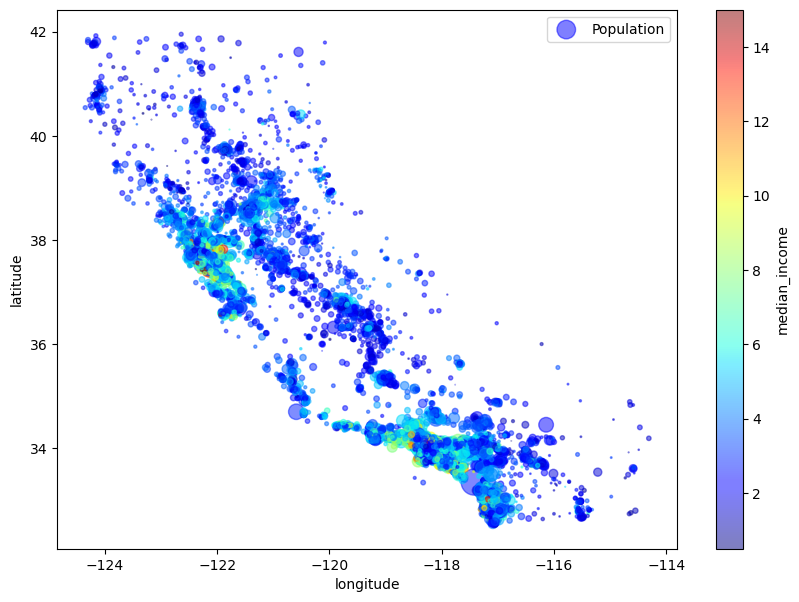

In [19]:
# Giá nhà ở California: Màu đỏ là đắt, màu xanh là rẻ, hình tròn lớn có mật độ dân số cao. Scale tỷ lệ dân số để trực quan dễ dàng hơn

Data_Visualization.plot(kind='scatter', x = "longitude", y = 'latitude', alpha = 0.5, 
                        s = Data_Visualization["population"]/100, label = 'Population', figsize = (10,7),
                        c = "median_income", cmap = plt.get_cmap("jet"),
                        colorbar = True
                        )
plt.legend()

Có một số điểm quan trọng từ những hình ảnh này:

*   Giá nhà liên quan đến vị trí (gần biển) và mật độ dân số..
*   Những người có thu nhập cao thường mua nhà ở thành phố lớn, gần biển ~ Có thể đặc trưng này có mối quan hệ với giá nhà


## Hình dung mối quan hệ giữa các đặc trưng

In [20]:
Data_Visualization

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,INLAND
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,NEAR OCEAN
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,INLAND
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,112500.0,NEAR OCEAN
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,238300.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900,268500.0,<1H OCEAN
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139,90400.0,INLAND
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797,140400.0,<1H OCEAN
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964,258100.0,<1H OCEAN


In [21]:
Corr_matrix = Data_Visualization.corr(numeric_only=True)
Corr_matrix['median_house_value'].sort_values(ascending = False)


median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

Từ ma trận, chúng ta có thể thấy rằng giá nhà có độ tương quan cao với thu nhập. Trong thực tế, điều này là đúng!

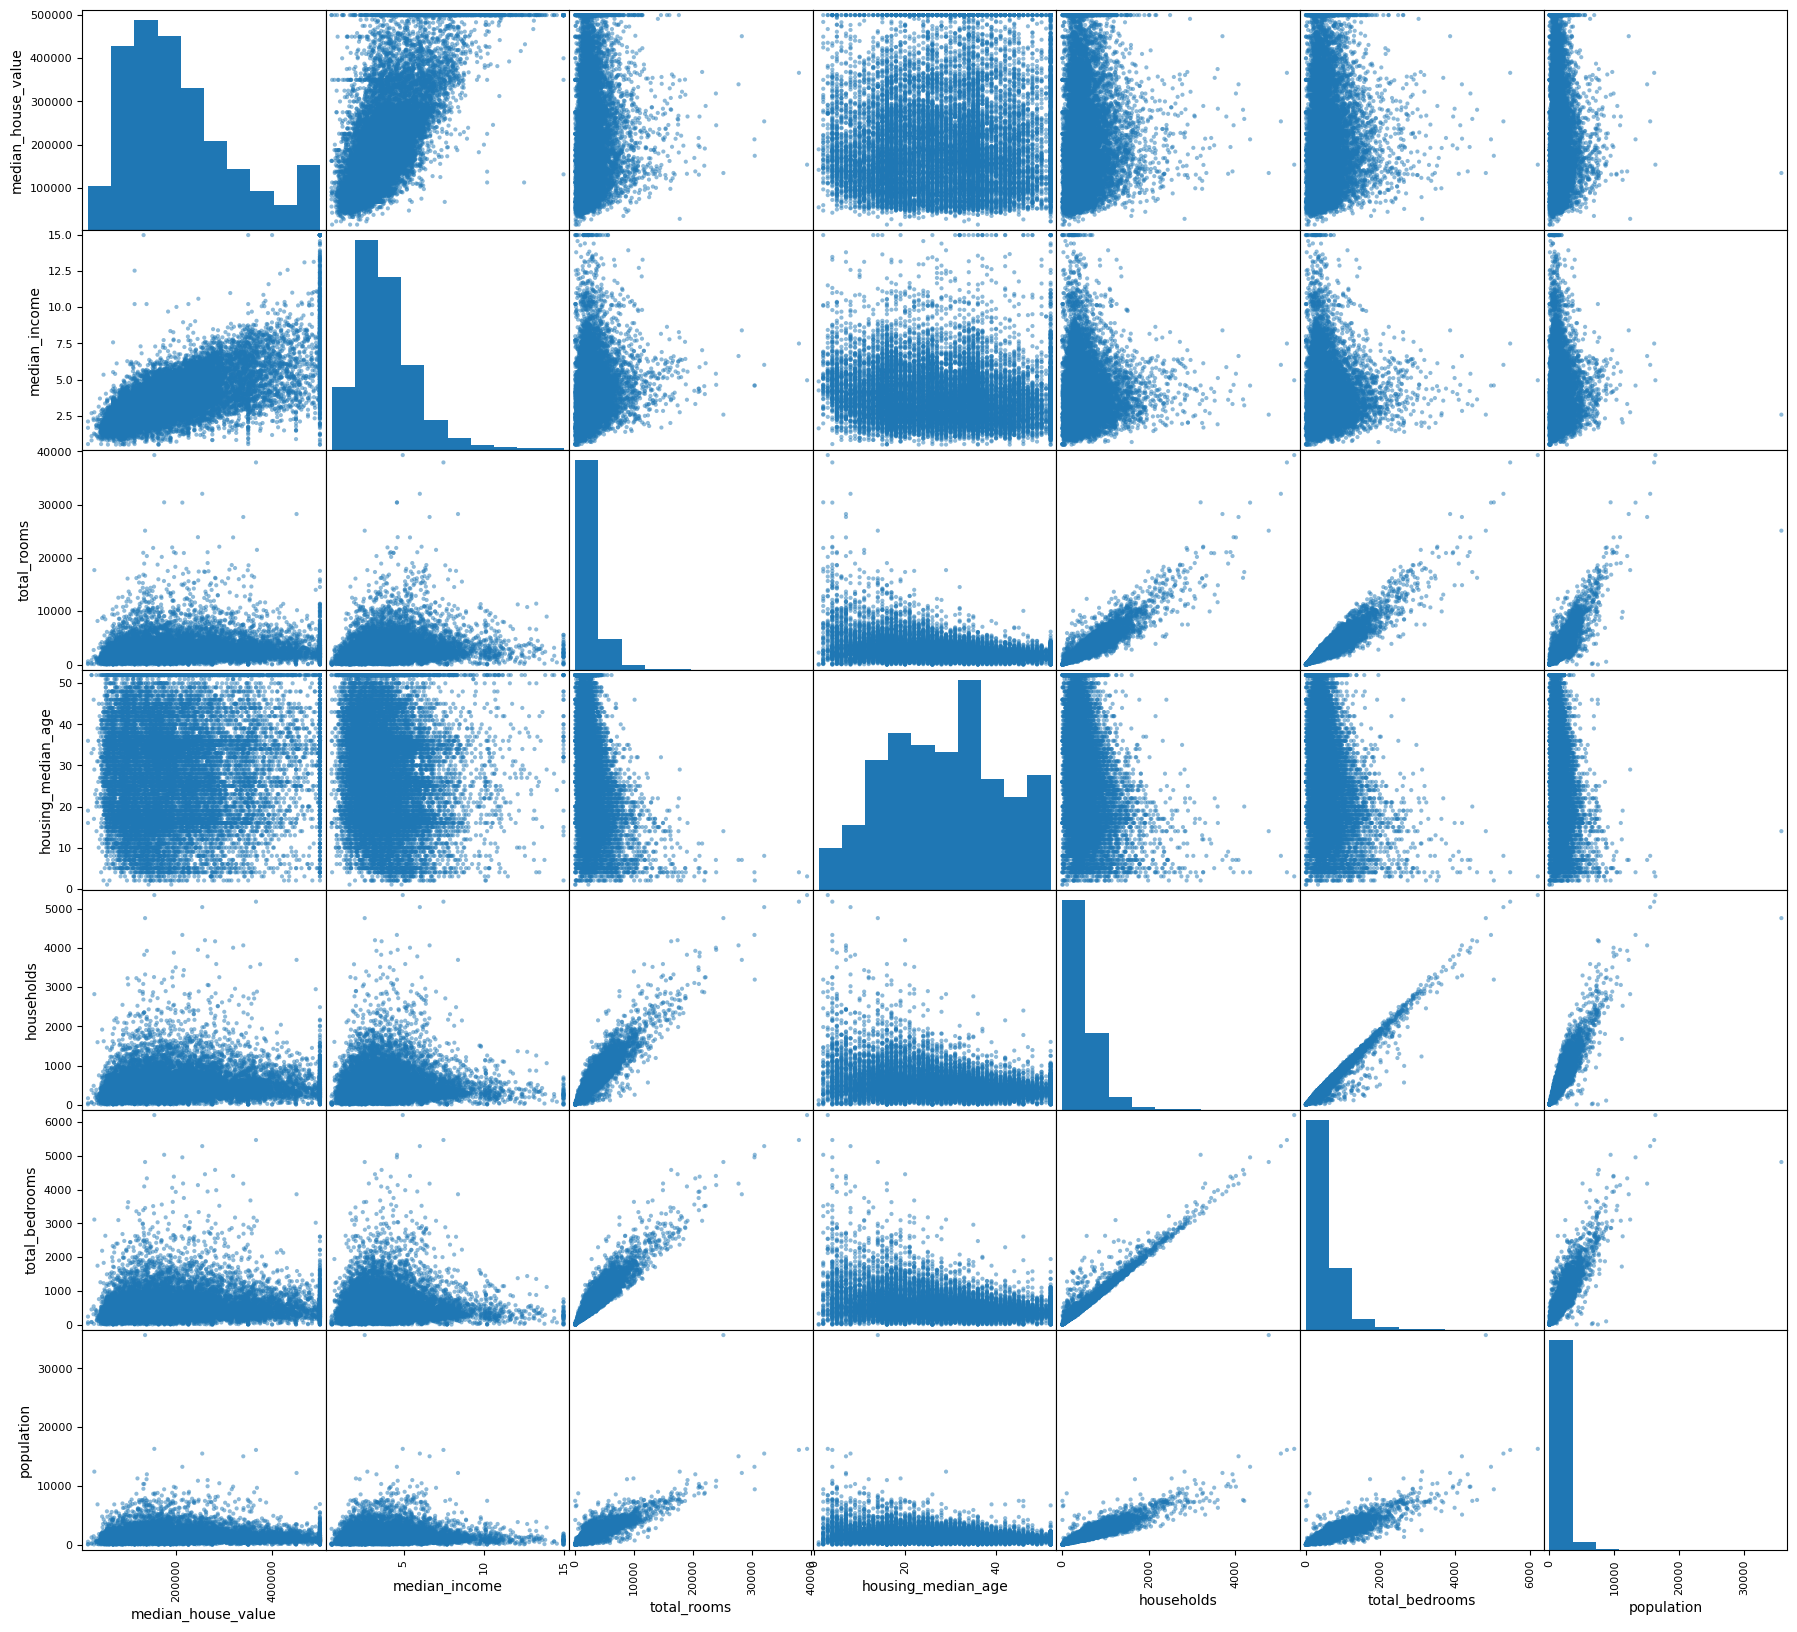

In [22]:
from pandas.plotting import scatter_matrix
scatter_matrix(Data_Visualization[['median_house_value', 'median_income', 'total_rooms', 'housing_median_age', 'households', 'total_bedrooms', 'population']], figsize= (22,20))
plt.show()

Có một số điểm quan trọng từ những hình ảnh này:

1.  Thu nhập trung bình thực sự có mối tương quan với giá trị nhà.
2.   Số hộ gia đình có độ tương quan cao với tổng số phòng, và tổng số phòng không phải là thông tin rất hữu ích nếu chúng ta không biết có bao nhiêu hộ gia đình trong khu vực đó => Nên kết hợp 2 đặc trưng thành 1 đặc trưng được gọi là tổng số phòng trung bình mỗi hộ gia đình. 
3. Tương tự như số phòng ngủ và tổng số phòng, chúng ta nên kết hợp những đặc trưng này thành tỉ lệ số phòng ngủ trên tổng số phòng.
4. Số dân trung bình mỗi hộ gia đình cũng có vẻ là một đặc trưng thú vị có mối tương quan với giá nhà.


## Kết hợp các đặc trưng để có đặc trưng hữu ích hơn.

In [23]:
Data_Visualization['Room_per_household'] = Data_Visualization['total_rooms']/Data_Visualization['households']
Data_Visualization['bedroom_per_room'] = Data_Visualization['total_bedrooms']/Data_Visualization['total_rooms']
Data_Visualization['Population_per_household'] = Data_Visualization['population']/Data_Visualization['households']

In [24]:
Corr_matrix = Data_Visualization.corr(numeric_only=True)
Corr_matrix['median_house_value'].sort_values(ascending = False)

median_house_value          1.000000
median_income               0.687151
Room_per_household          0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
Population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedroom_per_room           -0.259952
Name: median_house_value, dtype: float64

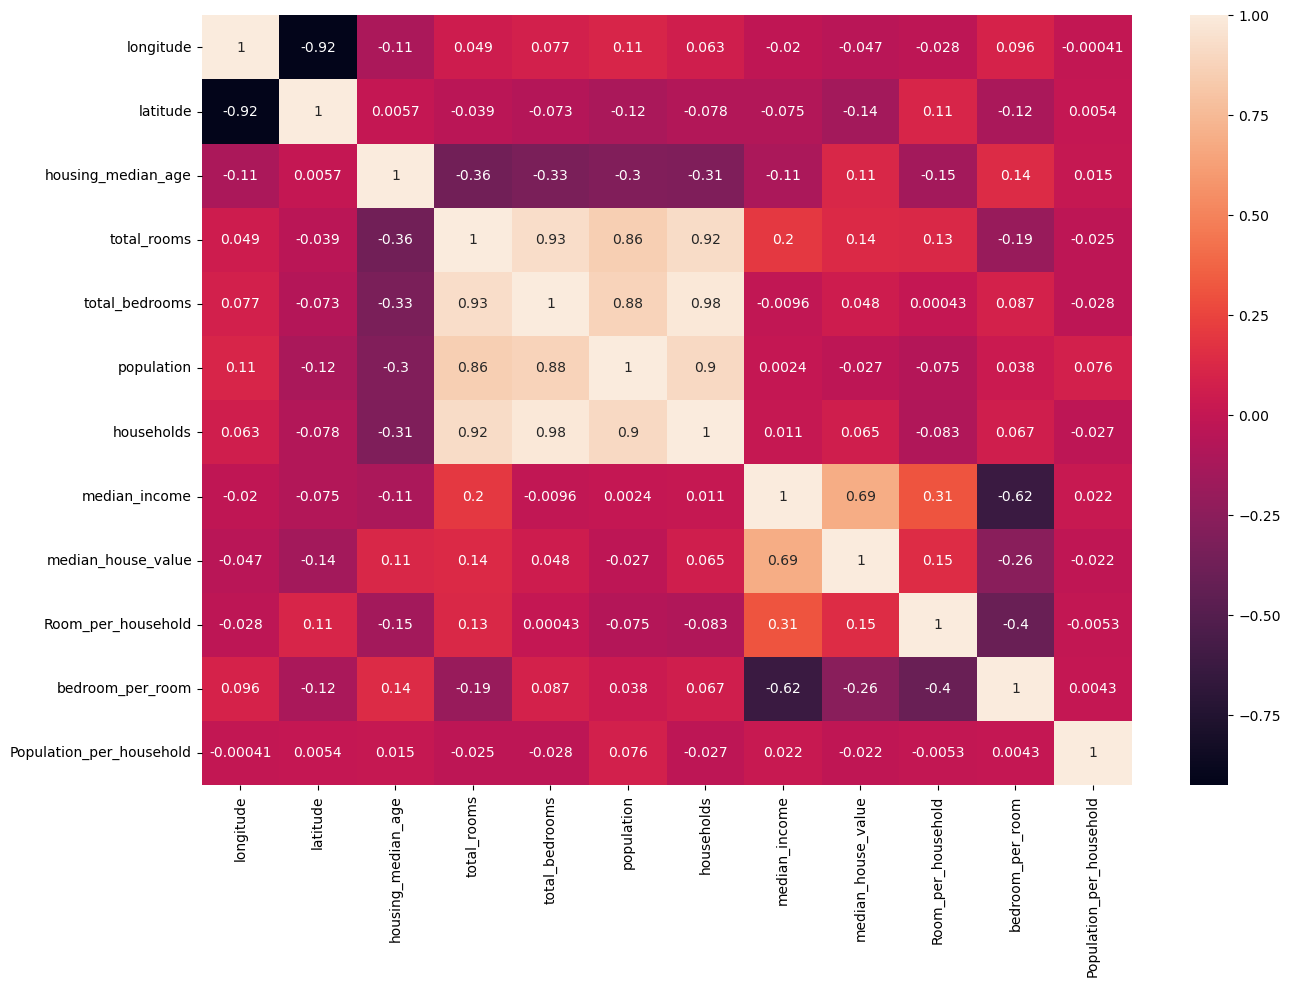

In [25]:
# Vẽ biểu đồ heatmap cho tương quan giữa các thuộc tính.
import seaborn as sns
plt.figure(figsize=(15, 10))
ax = sns.heatmap(Corr_matrix, annot=True)


# Bước 4: Chuẩn bị dữ liệu cho các thuật toán Machine Learning.







Có một số ghi chú về việc viết hàm trước khi chuẩn bị thuật toán Machine Learning:


*   Chúng ta có thể tái sử dụng các hàm dễ dàng trên bất kỳ bộ dữ liệu hoặc dự án tương lai nào.
*   Sử dụng những hàm này trong hệ thống thực để biến đổi dữ liệu mới trước khi đưa vào thuật toán.
* Dễ dàng thử nghiệm các biến đổi khác nhau và xem xét xem kết hợp biến đổi nào hoạt động tốt nhất.





## Phân tách các dự đoán và nhãn mục tiêu.

In [26]:
housing = strat_train_set.drop("median_house_value", axis = 1)
housing_target = strat_train_set["median_house_value"].copy()

## Điền giá trị cho dữ liệu còn thiếu.


In [27]:
# Sử dụng SimpleImputer từ Scikit-Learn để xử lý giá trị còn thiếu.
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = "median")

# Vì SimpleImputer chỉ được sử dụng với các thuộc tính số học, chúng ta cần loại bỏ các đặc trưng ocean_proximity.
housing_num = housing.drop("ocean_proximity", axis = 1)
# Fit dữ liệu housing_num vào hàm SimpleImputer.

imputer.fit(housing_num)
print('The medium of each feature by Imputer method:',imputer.statistics_)
print('The medium of each feature by manually calculating:',housing_num.median().values)
# Thay thế dữ liệu còn thiếu bằng giá trị trung bình.
X = imputer.transform(housing_num)
housing_tras = pd.DataFrame(X, columns=housing_num.columns, index = housing_num.index)
housing_tras.info()


The medium of each feature by Imputer method: [-118.51      34.26      29.      2119.       433.      1164.
  408.         3.54155]
The medium of each feature by manually calculating: [-118.51      34.26      29.      2119.       433.      1164.
  408.         3.54155]
<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


## Xử lý các thuộc tính văn bản và phân loại.

In [28]:
Housing_categories = housing[["ocean_proximity"]]
Housing_categories.head(7)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN


Có hai cách để xử lý các đặc trưng văn bản và phân loại:

*   Encoder theo thứ tự (Ordinal Encoder): Lớp này giả định rằng hai giá trị gần nhau thì tương tự nhau hơn so với hai giá trị xa nhau. Ví dụ: Kém, tốt, xuất sắc ~ 1, 2, 3





* One-hot encoding: Xử lý trường hợp ngược lại, trong đó các giá trị xa nhau tương tự hơn so với các giá trị gần nhau. Ví dụ: Vị trí, màu sắc,









In [29]:
# ordinal encoder:
from sklearn.preprocessing import OrdinalEncoder
Ordinal_encoder = OrdinalEncoder()
Housing_cate_encoded = Ordinal_encoder.fit_transform(Housing_categories)
print(Housing_cate_encoded[:7])
print(Ordinal_encoder.categories_)

[[1.]
 [4.]
 [1.]
 [4.]
 [0.]
 [3.]
 [0.]]
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


In [30]:
# One-hot encoding
from sklearn.preprocessing import OneHotEncoder
Onehot_encoder = OneHotEncoder()
Housing_cate_onehot = Onehot_encoder.fit_transform(Housing_categories)
print(Housing_cate_onehot.toarray())
print(Onehot_encoder.categories_)

[[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 ...
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


## Tùy chỉnh Transformer



*   Mặc dù Scikit-learn cung cấp nhiều bộ biến đổi hữu ích, nhưng chúng ta cần viết các bước như clean dữ liệu hoặc kết hợp các đặc trưng cụ thể.
*   Nếu chúng ta muốn các Transformer của mình hoạt động mượt mà với các hàm của scikit-learn, chúng ta cần tạo một lớp và triển khai 3 phương thức: fit(), transform(), fit_transform().
*   Chúng ta có thể nhận được phương thức cuối cùng miễn phí bằng cách đơn giản thêm TransformerMixin làm lớp cơ sở.
*   Chúng ta cũng sẽ có hai phương thức bổ sung (get_params() và set_params) sẽ hữu ích cho việc điều chỉnh siêu tham số tự động.


In [31]:
from sklearn.base import  BaseEstimator, TransformerMixin

room_id, bedroom_id, population_id, households_id = 3,4,5,6

class CombineAttributeAdder(BaseEstimator, TransformerMixin):
  def __init__(self, add_bedrooms_per_room = True):
    self.add_bedrooms_per_room = add_bedrooms_per_room
  def fit(self,X, y = None):
    return self
  def transform(self,X):
    rooms_per_household = X[:, room_id]/X[:, households_id]
    population_per_household = X[:, population_id]/X[:, households_id]
    if self.add_bedrooms_per_room:
      bedrooms_per_room = X[:, bedroom_id]/X[:, room_id]
      return np.c_[X,rooms_per_household,population_per_household,  bedrooms_per_room]
    else:
      return np.c_[X,rooms_per_household,population_per_household]

In [32]:
attribute_adder = CombineAttributeAdder(add_bedrooms_per_room=False)
Housing_extra_att = attribute_adder.transform(housing.values)

## Chuẩn hóa đặc trưng

Có 2 cách để chuẩn hoá các đặc trưng:


1.  Min-max scaling (Normalization): Giá trị được chuẩn hóa trong khoảng [0,1] bằng cách trừ giá trị tối thiểu và chia cho hiệu giữa giá trị tối đa và giá trị tối thiểu. Phương pháp này nhạy cảm với các giá trị ngoại lệ.

2. Standardization: Trừ giá trị cho giá trị trung bình và sau đó chia cho độ lệch chuẩn. Không có giới hạn giá trị cho phương pháp này, và nó không phù hợp cho mạng nơ-ron.

Chúng ta có thể kết hợp bước này vào bước tiếp theo được gọi là: Transformation Pipelines 


## Transformation pipeline

Có nhiều bước biến đổi dữ liệu cần được thực hiện theo đúng thứ tự, chúng ta có thể sử dụng Scikit-learn Pipeline để hỗ trợ chuỗi các bước biến đổi.







In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
                         ("Missing_data_filling", SimpleImputer(strategy = "median")),
                         ("Attribue_adder", CombineAttributeAdder()),
                         ("Standarization", StandardScaler())
])

housing_num_tr = num_pipeline.fit_transform(housing_num)

# Chúng ta có thể sử dụng ColumnTransformer để biến đổi từng cột trong DataFrame của Pandas, nó phù hợp để kết hợp dữ liệu Số học và dữ liệu Phân loại.
from sklearn.compose import ColumnTransformer

num_attribute = list(housing_num)
cat_attribute = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
                                  ("Num", num_pipeline, num_attribute),
                                   ("Cat", OneHotEncoder(), cat_attribute)
])

housing_prepared = full_pipeline.fit_transform(housing)

In [34]:
housing_prepared.shape

(16512, 16)

# Bước 5: Lựa chọn và huấn luyện mô hình

## Huấn luyện và Đánh giá trên Bộ huấn luyện

In [35]:
# Cố gắng sử dụng mô hình Hồi quy Tuyến tính để điều chỉnh mô hình.

from sklearn.ensemble import RandomForestRegressor
RF_reg = RandomForestRegressor()
RF_reg.fit(housing_prepared, housing_target)
#Evaluate it on the training set
from sklearn.metrics import mean_squared_error
Housing_prediction = RF_reg.predict(housing_prepared)
RF_mse = mean_squared_error(housing_target,Housing_prediction)
RF_rmse = np.sqrt(RF_mse)

In [36]:
print(RF_rmse)

18719.951481677756


Khi chúng ta huấn luyện và đánh giá trên bộ huấn luyện, hiệu suất trên bộ huấn luyện thường rất tốt, nhưng có khả năng chúng ta sẽ bị overfiting trên tập dữ liệu huấn luyện. Để đảm bảo rằng mô hình của chúng ta có overfiting hay không, chúng ta có thể đánh giá mô hình trên tập dữ liệu kiểm thử.

## Đánh giá tốt hơn bằng cách sử dụng K-fold cross-validation

K-fold Cross validation, chúng ta có thể chia tập dữ liệu huấn luyện thành k phần, chọn k-1 phần để huấn luyện và phần còn lại để kiểm tra mô hình, lặp lại quá trình này k lần. Tập huấn luyện và kiểm tra trong quá trình chia k-fold là khác nhau.

In [37]:
from sklearn.model_selection import cross_val_score
# cv=3 for responsive browser execution
rf_score = cross_val_score(RF_reg, housing_prepared, housing_target, scoring = "neg_mean_squared_error", cv = 3)
rf_rmse_scores = np.sqrt(-rf_score)

In [38]:
# Display scores
def display_scores(Score):
  print("Score is here:", Score)
  print("Mean of Score is here:", Score.mean())
  print("Standard deviation of Score is here:", Score.std())
display_scores(rf_rmse_scores)

Score is here: [51314.93026125 48934.18335743 46650.11692213 51991.10938273
 47623.8201693  51379.80999841 52748.02315039 49818.83454041
 48631.00742313 53811.79412469]
Mean of Score is here: 50290.362932987206
Standard deviation of Score is here: 2207.8633809920125


# Bước 6: Tinh chỉnh mô hình

## Grid Search



1.   Thông thường, chúng ta sẽ thay đổi siêu tham số để tìm ra hiệu suất tốt nhất của mô hình.

2.   Việc thay đổi thủ công các siêu tham số tốn thời gian, không phù hợp với mô hình có nhiều siêu tham số.

3. Một phương pháp gọi là tìm kiếm lưới (grid search) để triển khai tất cả các siêu tham số mà bạn muốn thử nghiệm và giá trị nào để thử nghiệm. Phương pháp này cũng sử dụng K-fold Cross-Validation để đánh giá mô hình.


In [39]:
from sklearn.model_selection import GridSearchCV

# Tinh chỉnh danh sách siêu tham số tối ưu cho môi trường trình duyệt
Param_grid = [
              {'n_estimators': [3, 10], 'max_features': [2, 4]}
              ]

forest_reg = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(forest_reg, Param_grid, cv = 2, scoring = 'neg_mean_squared_error', return_train_score = True)
grid_search.fit(housing_prepared, housing_target)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [40]:
grid_search.best_params_

{'max_features': 4, 'n_estimators': 30}

In [41]:
grid_search.best_estimator_

RandomForestRegressor(max_features=4, n_estimators=30)

In [42]:
# Đánh giá điểm số cho tất cả các siêu tham số.

Result = grid_search.cv_results_
for mean_score, params in zip(Result['mean_test_score'], Result['params']):
  print(np.sqrt(-mean_score),params )

64270.03950621739 {'max_features': 2, 'n_estimators': 3}
55479.012550139116 {'max_features': 2, 'n_estimators': 10}
52457.73690590721 {'max_features': 2, 'n_estimators': 30}
59931.72696958014 {'max_features': 4, 'n_estimators': 3}
53006.37824568462 {'max_features': 4, 'n_estimators': 10}
50079.33417375983 {'max_features': 4, 'n_estimators': 30}
59940.449049462535 {'max_features': 6, 'n_estimators': 3}
52607.03109193479 {'max_features': 6, 'n_estimators': 10}
50116.84977877656 {'max_features': 6, 'n_estimators': 30}
58933.735872090445 {'max_features': 8, 'n_estimators': 3}
51915.539281320234 {'max_features': 8, 'n_estimators': 10}
50091.268020017334 {'max_features': 8, 'n_estimators': 30}
61362.40193533032 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54115.85606679879 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
59450.730494355186 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52721.11066213126 {'bootstrap': False, 'max_features': 3, 'n_estimator

Chúng ta có thể đạt được giải pháp tốt nhất bằng cách đặt max_feature: 6, n_estimators: 30, với RMSE là 50030.58880140146.


## Randomized Search


Phương pháp tìm kiếm lưới là phù hợp khi chúng ta đang khám phá một số kết hợp tương đối ít. Khi có nhiều siêu tham số, chúng ta có thể sử dụng RandomizedSearchCV để có giải pháp tốt hơn. Có 2 lợi ích cho phương pháp này:
*   Nếu chúng ta huấn luyện mô hình với 1000 lần lặp, phương pháp này sẽ huấn luyện với 1000 giá trị khác nhau cho mỗi siêu tham số thay vì một số giá trị cố định trong khoảng như Grid Search.
*   Chỉ cần đặt số lần lặp.

## Ensemble methods

Phương pháp tổ hợp (ensemble) mang lại một số lợi ích:


*  Một cách khác để điều chỉnh mô hình là thử nghiệm việc kết hợp các mô hình cá nhân hiệu quả nhất.
*   Phương pháp tổ hợp thường sẽ thực hiện tốt hơn so với mô hình cá nhân tốt nhất (Random Forest là một ví dụ cho việc kết hợp mô hình cây quyết định với các tập con đặc trưng khác nhau để huấn luyện).

## Phân tích mô hình tốt nhất và các lỗi của chúng.


Thường ta sẽ đạt được những thông tin quý giá về vấn đề bằng cách kiểm tra các mô hình tốt nhất. Trong phương pháp Random Forest, nó có thể cung cấp độ quan trọng tương đối của mỗi đặc trưng để đưa ra dự đoán chính xác.


In [43]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([8.08430128e-02, 7.46162803e-02, 4.53612451e-02, 2.48771289e-02,
       1.99976360e-02, 2.41328544e-02, 2.06935898e-02, 2.60062924e-01,
       8.73575022e-02, 1.01438186e-01, 8.95848054e-02, 2.63276849e-02,
       1.25929565e-01, 8.55400379e-05, 6.41378906e-03, 1.22782553e-02])

In [44]:
extra_feature = ["room_per_hh", "PoP_per_hh", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["Cat"]
Cat_one_hot_features = list(cat_encoder.categories_[0])
Features = num_attribute + extra_feature + Cat_one_hot_features
sorted(zip(feature_importances, Features), reverse=True)

[(0.260062924007479, 'median_income'),
 (0.12592956541002306, 'INLAND'),
 (0.1014381864068545, 'PoP_per_hh'),
 (0.0895848054063562, 'bedrooms_per_room'),
 (0.08735750217405139, 'room_per_hh'),
 (0.08084301284522878, 'longitude'),
 (0.07461628034695278, 'latitude'),
 (0.04536124507848915, 'housing_median_age'),
 (0.026327684859172487, '<1H OCEAN'),
 (0.024877128860488946, 'total_rooms'),
 (0.024132854365124634, 'population'),
 (0.02069358982319901, 'households'),
 (0.01999763602026291, 'total_bedrooms'),
 (0.012278255301393573, 'NEAR OCEAN'),
 (0.006413789057002973, 'NEAR BAY'),
 (8.554003792059025e-05, 'ISLAND')]



*   Với thông tin này, nó hữu ích cho việc lựa chọn đặc trưng để cố gắng loại bỏ một số đặc trưng ít quan trọng.
*   Chúng ta nên cố gắng xem xét các lỗi cụ thể mà hệ thống của chúng ta gặp phải, cố gắng hiểu tại sao sau đó cố gắng khắc phục các vấn đề.

## Đánh giá mô hình trên tập kiểm thử.

In [45]:
final_model = grid_search.best_estimator_
X_test = strat_test_set.drop("median_house_value", axis = 1)
Y_test = strat_test_set["median_house_value"].copy()
X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)
final_mse = mean_squared_error(Y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_rmse

48028.15941004228

Chúng ta có thể tính toán khoảng tin cậy 95% cho lỗi kiểm thử để xem độ chính xác của ước lượng mô hình là như thế nào.

In [46]:
from scipy import stats
confidence = 0.95
squared_errors = (final_predictions - Y_test)**2
np.sqrt(stats.t.interval(confidence, len(squared_errors)-1, loc = squared_errors.mean(), scale = stats.sem(squared_errors)))

array([46108.41100329, 49874.06768437])

# Bước 7: Trình bày kết quả

* Tài liệu hoá tất cả quy trình, code trong dự án
* Tạo một bài thuyết trình thuyết phục và dễ hiểu: Đảm bảo trình bày tốt về tổng quan vấn đề
* Giải thích kết quả đạt được giải quyết được vấn đề gì cho bài toán đặt ra ban đầu
* Đừng quên trình bày những điểm thú vị bạn nhận thấy trong suốt quá trình.
* Đảm bảo những phát hiện quan trọng của bạn được truyền đạt thông qua các hình ảnh đẹp hoặc các tuyên bố dễ nhớ.














# Bước 8: Triển khai, Giám sát và Bảo trì hệ thống



Cách triển khai mô hình Machine Learning:

1.   Một cách để làm điều này là lưu mô hình đã được huấn luyện bằng cách sử dụng *joblib*, bao gồm toàn bộ đường ống xử lý và dự đoán, sau đó tải mô hình đã được huấn luyện vào môi trường sản xuất và sử dụng nó để thực hiện dự đoán.

2.   Chúng ta có thể đóng gói mô hình trong một dịch vụ web riêng biệt mà ứng dụng web của chúng ta có thể truy vấn thông qua một REST API.
3.   Chiến lược phổ biến khác là triển khai mô hình lên đám mây.

Triển khai không phải là cuối cùng của dự án. Đúng, chúng ta cần duy trì hệ thống:

1.   Chúng ta cần viết mã giám sát để kiểm tra hiệu suất thực tế của hệ thống định kỳ và kích hoạt cảnh báo khi nó giảm.

Huấn luyện lại mô hình với dữ liệu mới: Chúng ta cần tự động hóa toàn bộ quy trình càng nhiều càng tốt để dễ dàng huấn luyện lại mô hình.

1.  Thu thập dữ liệu mới thường xuyên và gán nhãn cho nó.
2.  Viết một đoạn mã để tự động huấn luyện mô hình và điều chỉnh siêu tham số, chạy nó hàng tuần, hàng tháng. Tuỳ thuộc vào nhu cầu.

3. Viết một đoạn mã khác để đánh giá cả mô hình mới và mô hình trước đó trên tập kiểm thử được cập nhật, triển khai mô hình vào sản xuất và đo lường độ chính xác.





4. Một số điều cần nhớ:


>* Giám sát chất lượng đầu vào của mô hình.

>* Đảm bảo lưu trữ bản sao lưu của mỗi mô hình đã tạo và có quy trình và công cụ để quay trở lại mô hình trước đó nhanh chóng, trong trường hợp mô hình mới thất bại nghiêm trọng vì lý do nào đó.









